Training samples: 1744
Testing samples: 437

--- Model Evaluation ---
Mean Squared Error (MSE): 0.0005
Root Mean Squared Error (RMSE): 0.0220
R-squared (Variance Explained): 86.49%


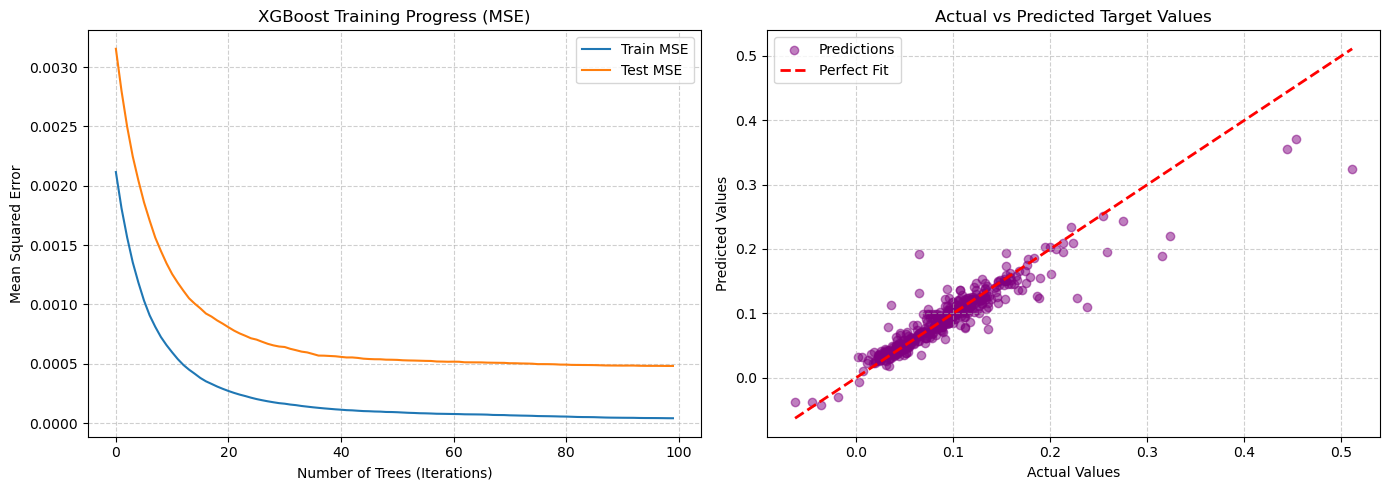

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('/Users/andydascikid/Python Scripts/Home/Yamuna Water Analysis/CSV Files/Final Dataset.csv')

df_dropped = df.drop(columns=['Date'])

df_dropped = df_dropped.rename(columns={
    'Rainfall [mm]':'Rainfall',
    'Air Temperature [C]':'Air Temperature',
    'Wind Speed [m/s]':'Wind Speed',
    'Relative Humidity (%)':'Relative Humidity',
    'Solar Radiation [MJ/m^2]':'Solar Radiation',
    'Water Surface Temperature [C]':'Water Surface Temperature',
    'NDTI':'NDTI',
    'pH':'pH',
    'COD (mg/L)':'COD',
    'BOD (mg/L)':'BOD',
    'TSS':'TSS',
    'Oil & Grease (mg/L)':'Oil & Grease',
    'Ammonical Nitrogen (mg/L)':'Ammonical Nitrogen',
    'NDCI':'NDCI'
})


X = df_dropped.iloc[:, :-1] 
y = df_dropped.iloc[:, -1]  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

model = xgb.XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=6, 
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred) 

print("\n--- Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (Variance Explained): {r2 * 100:.2f}%")

results = model.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(x_axis, np.square(results['validation_0']['rmse']), label='Train MSE')
plt.plot(x_axis, np.square(results['validation_1']['rmse']), label='Test MSE')
plt.legend()
plt.ylabel('Mean Squared Error')
plt.xlabel('Number of Trees (Iterations)')
plt.title('XGBoost Training Progress (MSE)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, color='purple', alpha=0.5, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.legend()
plt.ylabel('Predicted Values')
plt.xlabel('Actual Values')
plt.title('Actual vs Predicted Target Values')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Training set size: 1744 samples
Testing set size: 437 samples

[0]	validation_0-rmse:0.05880
[100]	validation_0-rmse:0.02479
[200]	validation_0-rmse:0.02158
[300]	validation_0-rmse:0.02082
[400]	validation_0-rmse:0.02050
[500]	validation_0-rmse:0.02033
[600]	validation_0-rmse:0.02023
[700]	validation_0-rmse:0.02018
[800]	validation_0-rmse:0.02014
[900]	validation_0-rmse:0.02011
[1000]	validation_0-rmse:0.02011
[1100]	validation_0-rmse:0.02010
[1200]	validation_0-rmse:0.02010
[1258]	validation_0-rmse:0.02010

Training stopped early at tree choice: 1208

================ MODEL PERFORMANCE ================
Metric  Train Set  Test Set
  RMSE   0.000683  0.020097
   MAE   0.000512  0.009976
    R2   0.999811  0.886776



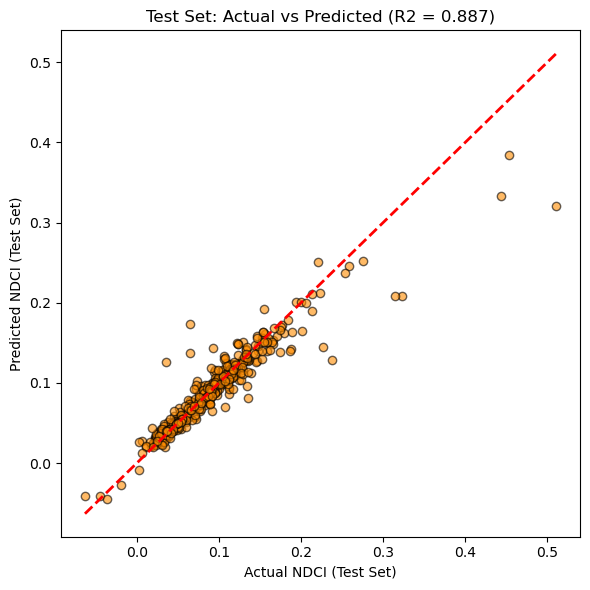

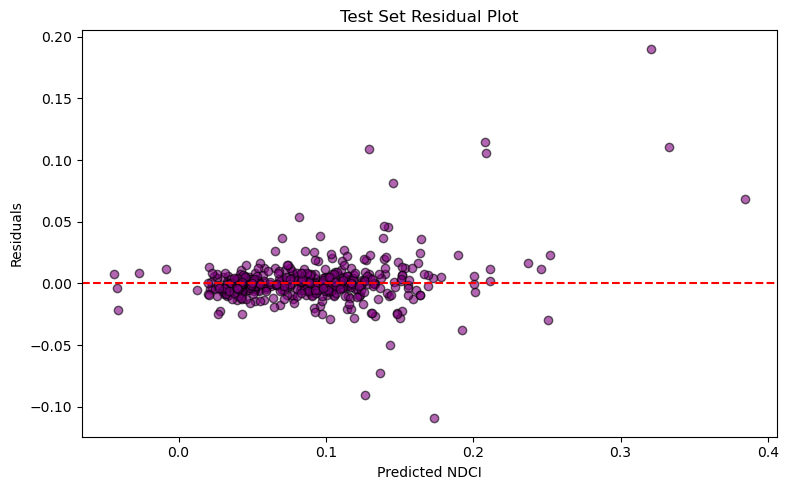

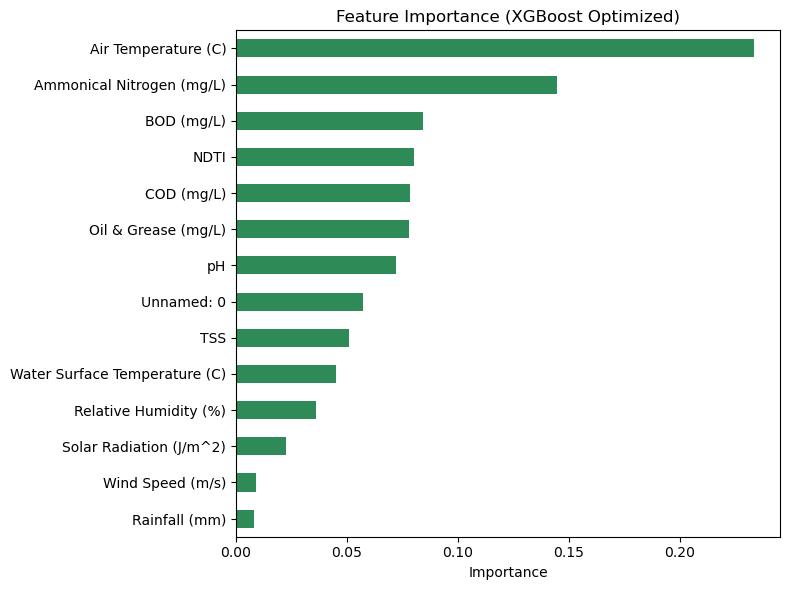

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

df = pd.read_csv('/Users/andydascikid/Python Scripts/Home/Yamuna Water Analysis/CSV Files/Final Dataset.csv')

df_dropped = df.drop(columns=['Date', 'Unnamed: 0'])

df_dropped = df_dropped.rename(columns={
    'Rainfall [mm]':'Rainfall',
    'Air Temperature [C]':'Air Temperature',
    'Wind Speed [m/s]':'Wind Speed',
    'Relative Humidity (%)':'Relative Humidity',
    'Solar Radiation [MJ/m^2]':'Solar Radiation',
    'Water Surface Temperature [C]':'Water Surface Temperature',
    'NDTI':'NDTI',
    'pH':'pH',
    'COD (mg/L)':'COD',
    'BOD (mg/L)':'BOD',
    'TSS':'TSS',
    'Oil & Grease (mg/L)':'Oil & Grease',
    'Ammonical Nitrogen (mg/L)':'Ammonical Nitrogen',
    'NDCI':'NDCI'
})

TARGET = "NDCI"
FEATURES = [c for c in df.columns if c != TARGET and c != "Date"]

X = df[FEATURES].copy()
X.columns = [c.replace('[','(').replace(']',')').replace('<','lt') for c in X.columns]
FEATURES = list(X.columns)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples\n")

model = XGBRegressor(
    n_estimators=12000,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50  
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100  
)

print(f"\nTraining stopped early at tree choice: {model.best_iteration}")

train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

metrics = {
    "Metric": ["RMSE", "MAE", "R2"],
    "Train Set": [
        np.sqrt(mean_squared_error(y_train, train_preds)),
        mean_absolute_error(y_train, train_preds),
        r2_score(y_train, train_preds)
    ],
    "Test Set": [
        np.sqrt(mean_squared_error(y_test, test_preds)),
        mean_absolute_error(y_test, test_preds),
        r2_score(y_test, test_preds)
    ]
}

metrics_df = pd.DataFrame(metrics)

print(metrics_df.to_string(index=False))

output_df = df.copy()
output_df.loc[X_train.index, "NDCI_Predicted"] = train_preds
output_df.loc[X_test.index, "NDCI_Predicted"] = test_preds
output_df["Data_Partition"] = "Train"
output_df.loc[X_test.index, "Data_Partition"] = "Test"

plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_preds, alpha=0.6, edgecolor='k', color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual NDCI (Test Set)")
plt.ylabel("Predicted NDCI (Test Set)")
plt.title(f"Test Set: Actual vs Predicted (R2 = {metrics['Test Set'][2]:.3f})")
plt.tight_layout()
plt.savefig("test_actual_vs_predicted.png", dpi=150)
plt.show()

residuals_test = y_test - test_preds
plt.figure(figsize=(8, 5))
plt.scatter(test_preds, residuals_test, alpha=0.6, edgecolor='k', color='purple')
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted NDCI")
plt.ylabel("Residuals")
plt.title("Test Set Residual Plot")
plt.tight_layout()
plt.savefig("test_residual_plot.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 6))
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind='barh', color='seagreen')
plt.title("Feature Importance (XGBoost Optimized)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()